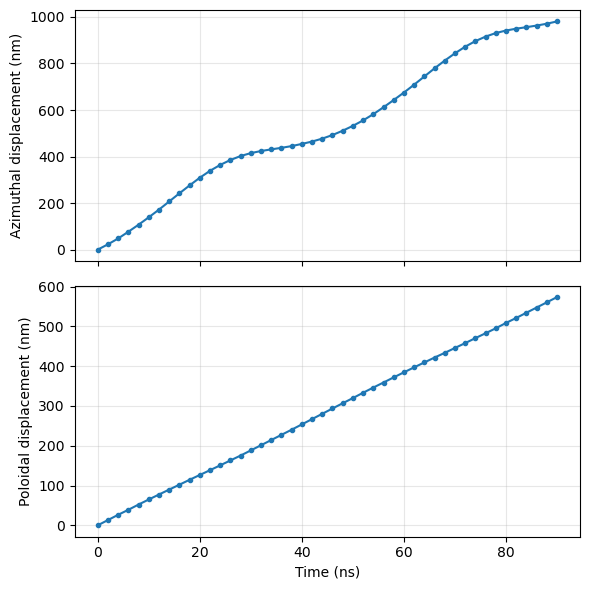

In [10]:
import glob
import re

import h5py
import numpy as np
import matplotlib.pyplot as plt

# Geometric parameters

major_radius = 180.0     # Major radius of the torus [nm]
minor_radius = 50.0      # Tube radius [nm]

output_dt = 2.0          
orientation = -1.0


# LOAD FILES 

h5files = sorted(
    glob.glob("STT_lind_gpu/*.h5"),
    key=lambda name: [
        int(token) if token.isdigit() else token.lower()
        for token in re.split(r"(\d+)", name)
    ]
)


# INITIALIZE TRAJECTORY VARIABLES


trajectory = []

azimuthal_displacement = 0.0
poloidal_displacement = 0.0

previous_azimuth = None
previous_poloidal_angle = None



# PROCESS EACH SAVED MAGNETIZATION STATE


for frame, filename in enumerate(h5files):

    with h5py.File(filename, "r") as h5:

        # Mesh coordinates
        points = h5["/Mesh/Grid/geometry"][:]

        # Magnetization field
        magnetization = h5["/Function/f/0"][:]

    
    # EXTRACT CARTESIAN COMPONENTS

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    mx = magnetization[:, 0]
    my = magnetization[:, 1]
    mz = magnetization[:, 2]


    # COMPUTE THE LOCAL OUTWARD NORMAL OF THE TORUS

    radial_distance = np.hypot(x, y)

    tube_distance = np.sqrt((radial_distance - major_radius) ** 2 + z ** 2)

    nx = (radial_distance - major_radius) / tube_distance* x / radial_distance 
    ny = (radial_distance - major_radius) / tube_distance* y / radial_distance
    nz = z / tube_distance

    # PROJECT THE MAGNETIZATION ONTO THE LOCAL NORMAL

    normal_component = mx * nx + my * ny+ mz * nz

    # LOCATE THE SKYRMION CORE


    core_nodes = np.where(normal_component < -0.9)[0]


    # ESTIMATE THE SKYRMION CENTER


    center_x = x[core_nodes].mean()
    center_y = y[core_nodes].mean()
    center_z = z[core_nodes].mean()

    center_radial_distance = np.hypot(center_x,center_y)



    # COMPUTE TOROIDAL ANGLES


    azimuth = np.arctan2(center_y,center_x)

    poloidal_angle = np.arctan2(center_z,center_radial_distance - major_radius)


    # ACCUMULATE PHYSICAL DISPLACEMENTS ALONG THE TORUS


    if frame > 0:


        azimuth_increment = np.arctan2(np.sin(azimuth - previous_azimuth),np.cos(azimuth - previous_azimuth))
        poloidal_increment = np.arctan2(np.sin(poloidal_angle - previous_poloidal_angle),np.cos(poloidal_angle - previous_poloidal_angle))

        azimuthal_step = (major_radius+ minor_radius * np.cos(poloidal_angle)) * azimuth_increment

        poloidal_step =  minor_radius* poloidal_increment

        azimuthal_displacement += orientation* azimuthal_step

        poloidal_displacement +=  orientation* poloidal_step


    # STORE CURRENT STATE

    current_time = output_dt * frame

    trajectory.append([
        current_time,
        center_x,
        center_y,
        center_z,
        azimuth,
        poloidal_angle,
        azimuthal_displacement,
        poloidal_displacement,
    ])

    previous_azimuth = azimuth
    previous_poloidal_angle = poloidal_angle


trajectory = np.asarray(trajectory)

time = trajectory[:, 0]

delta_azimuthal = trajectory[:, 6]
delta_poloidal = trajectory[:, 7]

# PLOT DISPLACEMENTS

fig, axes = plt.subplots( 2,1,figsize=(6, 6),sharex=True)

axes[0].plot(time,-delta_azimuthal,"o-",  markersize=3)
axes[0].set_ylabel( r"Azimuthal displacement (nm)")
axes[0].grid(alpha=0.3)


axes[1].plot(time,-delta_poloidal,"o-",markersize=3)
axes[1].set_xlabel( "Time (ns)")
axes[1].set_ylabel( r"Poloidal displacement (nm)")
axes[1].grid(alpha=0.3)

# The calculated curves are in excellent agreement with those shown in Fig. S10(b) of the article.

plt.tight_layout()
plt.show()